In [81]:
from IPython.display import Image
import pandas as pd
import numpy as np

In [82]:
data = pd.read_csv('ks.csv')

In [83]:
data.head()

,Name,Category,Main category,Currency,Deadline,Publication date,Status,Investors,Country,Amount raised in dollars,Goal in dollars
0,"Don't Call it a Comeback ""Telescopes""",Music,Music,USD,2013-01-10,2012-12-09 06:03:52,successful,23,US,600.00,600.00
1,Arcade County (Canceled),Games,Games,USD,2012-04-29,2012-03-30 23:40:45,canceled,5,US,71.00,9000.00
2,Hayashi Skate Co. Solar Skateboard backpack,Accessories,Fashion,CAD,2017-07-22,2017-05-23 23:00:13,canceled,8,CA,360.36,2391.77
3,Me & You Coordinating Sunglasses- Optical Qual...,Accessories,Fashion,USD,2016-11-18,2016-10-19 22:06:41,failed,20,US,502.00,10000.00
4,New Carts for Istanbul Street Food Vendors,Food,Food,USD,2015-05-17,2015-04-17 18:10:47,successful,62,US,2414.00,1400.00


In [84]:
data.shape

(378661, 11)

In [85]:
### Keep only the relevant statuses

data = data[data['Status'].isin(['failed', 'successful'])]

### What do we use as the target? 2 options:

- We will solve a classification task: mark successful projects as 1, and failed ones as 0

- We can predict the amount of money raised directly, then check if it reaches the goal. That would be a regression task.

In [86]:
### Create target1 column (binary target)

data.loc[(data['Status'] == 'failed'), 'target1'] = 0
data['target1'] = data['target1'].fillna(1)

In [87]:
data = data.drop('Status', axis=1)

In [88]:
### Create target2 column (continuous/regression target)
data = data.rename({'target2':'target2'}, axis=1)
data.head()

,Name,Category,Main category,Currency,Deadline,Publication date,Investors,Country,Amount raised in dollars,Goal in dollars,target1
0,"Don't Call it a Comeback ""Telescopes""",Music,Music,USD,2013-01-10,2012-12-09 06:03:52,23,US,600.00,600.0,1.0
3,Me & You Coordinating Sunglasses- Optical Qual...,Accessories,Fashion,USD,2016-11-18,2016-10-19 22:06:41,20,US,502.00,10000.0,0.0
4,New Carts for Istanbul Street Food Vendors,Food,Food,USD,2015-05-17,2015-04-17 18:10:47,62,US,2414.00,1400.0,1.0
5,New Improv Comedy Venue in Des Moines,Theater,Theater,USD,2013-06-17,2013-05-03 16:17:21,86,US,10030.88,10000.0,1.0
6,The Seer and the Sword,Shorts,Film & Video,USD,2012-08-11,2012-07-12 05:19:53,0,US,0.00,10000.0,0.0


### To build a feature matrix, we often need to process raw data and extract features that are not explicitly given

In [89]:
### From date columns, compute the difference in days 
data['Launch_Date'] = pd.to_datetime(data['Publication date'])
data['Deadline'] = pd.to_datetime(data['Deadline'])

In [90]:
data['Duration'] = (data['Deadline'] - data['Launch_Date']).dt.days

In [91]:
### Extract the launch year of the project
data['Launch_Year'] = data['Launch_Date'].dt.year

In [92]:
data.head()

,Name,Category,Main category,Currency,Deadline,Publication date,Investors,Country,Amount raised in dollars,Goal in dollars,target1,Launch_Date,Duration,Launch_Year
0,"Don't Call it a Comeback ""Telescopes""",Music,Music,USD,2013-01-10,2012-12-09 06:03:52,23,US,600.00,600.0,1.0,2012-12-09 06:03:52,31,2012
3,Me & You Coordinating Sunglasses- Optical Qual...,Accessories,Fashion,USD,2016-11-18,2016-10-19 22:06:41,20,US,502.00,10000.0,0.0,2016-10-19 22:06:41,29,2016
4,New Carts for Istanbul Street Food Vendors,Food,Food,USD,2015-05-17,2015-04-17 18:10:47,62,US,2414.00,1400.0,1.0,2015-04-17 18:10:47,29,2015
5,New Improv Comedy Venue in Des Moines,Theater,Theater,USD,2013-06-17,2013-05-03 16:17:21,86,US,10030.88,10000.0,1.0,2013-05-03 16:17:21,44,2013
6,The Seer and the Sword,Shorts,Film & Video,USD,2012-08-11,2012-07-12 05:19:53,0,US,0.00,10000.0,0.0,2012-07-12 05:19:53,29,2012


### Sometimes it may seem like we have too few features. Think about what else could explain the target variable.

In [93]:
Macro = pd.read_excel("macrofeatures.xlsx", engine="openpyxl")

Macro.head()

,Unnamed: 0,Close_brent,Close_sugar,Close_cereals,Close_index_moex,Close_index_moex_10,Close_index_RGBI,Close_index_RTS_oil_and_gas,Close_index_RTS_metallurgy,Close_index_RTS_consumer_sector,Close_index_RTS_telecom,Close_index_RTS_finance,Close_index_RTS_transport,Close_index_RTS_chemicals,Close_index_RTS_broad_market,Close_index_RTS_electricity,dlk_cob_date
0,0,34.41,13.97,442.75,1797.27,3940.81,125.59,123.40,111.97,196.55,70.17,140.57,27.06,177.38,530.59,32.49,2016-02-24
1,1,35.06,14.24,445.25,1803.89,3977.35,126.44,124.22,112.51,198.03,70.56,142.64,27.43,179.48,536.20,33.07,2016-02-25
2,2,35.13,14.00,443.25,1816.73,4027.23,126.90,125.38,113.44,200.13,71.94,145.45,28.06,181.56,544.73,33.55,2016-02-26
3,3,36.64,14.36,445.00,1840.17,4084.24,126.87,126.69,114.66,200.32,72.41,147.22,28.49,186.76,552.82,34.41,2016-02-29
4,4,36.60,14.39,438.50,1844.17,4087.06,127.78,129.72,117.09,204.30,74.26,150.04,30.12,190.67,565.45,34.96,2016-03-01


In [94]:
### Merge columns. Keep just one macro feature for now.

Macro = Macro[['Close_brent', 'dlk_cob_date']].drop_duplicates()

In [95]:
Macro['dlk_cob_date'] = pd.to_datetime(Macro['dlk_cob_date'])

In [96]:
data['Launch_Date'] = data['Launch_Date'].dt.date.astype('datetime64[ns]')

In [97]:
data = pd.merge(data,
         Macro,
         left_on=['Launch_Date'],
         right_on=['dlk_cob_date'],
         how='left')

In [98]:
data = data.sort_values('Launch_Date')

In [99]:
data['Close_brent'] = data['Close_brent'].fillna(34.41)

In [100]:
data = data.drop(['Deadline', 'Launch_Date', 'dlk_cob_date'], axis=1)

In [101]:
data.head()

,Name,Category,Main category,Currency,Publication date,Investors,Country,Amount raised in dollars,Goal in dollars,target1,Duration,Launch_Year,Close_brent
176128,Grace Jones Does Not Give A F$#% T-Shirt (limi...,Fashion,Fashion,USD,2009-04-21 21:02:48,30,US,625.0,1000.0,0.0,39,2009,34.41
241929,CRYSTAL ANTLERS UNTITLED MOVIE,Shorts,Film & Video,USD,2009-04-23 00:07:53,3,US,22.0,80000.0,0.0,87,2009,34.41
244460,drawing for dollars,Illustration,Art,USD,2009-04-24 21:52:03,3,US,35.0,20.0,1.0,8,2009,34.41
80845,Offline Wikipedia iPhone app,Software,Technology,USD,2009-04-25 17:36:21,25,US,145.0,99.0,1.0,79,2009,34.41
181197,Pantshirts,Fashion,Fashion,USD,2009-04-27 14:10:39,10,US,387.0,1900.0,0.0,28,2009,34.41


### Finally, drop columns that we do not consider features

In [102]:
### Drop columns: Deadline, Launch Date, Backers, Name, Country

data = data.drop(['Name', 'Country'], axis=1)

In [103]:
data.head()

,Category,Main category,Currency,Publication date,Investors,Amount raised in dollars,Goal in dollars,target1,Duration,Launch_Year,Close_brent
176128,Fashion,Fashion,USD,2009-04-21 21:02:48,30,625.0,1000.0,0.0,39,2009,34.41
241929,Shorts,Film & Video,USD,2009-04-23 00:07:53,3,22.0,80000.0,0.0,87,2009,34.41
244460,Illustration,Art,USD,2009-04-24 21:52:03,3,35.0,20.0,1.0,8,2009,34.41
80845,Software,Technology,USD,2009-04-25 17:36:21,25,145.0,99.0,1.0,79,2009,34.41
181197,Fashion,Fashion,USD,2009-04-27 14:10:39,10,387.0,1900.0,0.0,28,2009,34.41


## One-hot Encoding

In [104]:
### One-hot Encoding for the Currency column

data = pd.concat((data, pd.get_dummies(data['Currency'])), axis=1)
data = data.drop(['Currency'], axis=1)

In [105]:
data.head()

,Category,Main category,Publication date,Investors,Amount raised in dollars,Goal in dollars,target1,Duration,Launch_Year,Close_brent,...,EUR,GBP,HKD,JPY,MXN,NOK,NZD,SEK,SGD,USD
176128,Fashion,Fashion,2009-04-21 21:02:48,30,625.0,1000.0,0.0,39,2009,34.41,...,False,False,False,False,False,False,False,False,False,True
241929,Shorts,Film & Video,2009-04-23 00:07:53,3,22.0,80000.0,0.0,87,2009,34.41,...,False,False,False,False,False,False,False,False,False,True
244460,Illustration,Art,2009-04-24 21:52:03,3,35.0,20.0,1.0,8,2009,34.41,...,False,False,False,False,False,False,False,False,False,True
80845,Software,Technology,2009-04-25 17:36:21,25,145.0,99.0,1.0,79,2009,34.41,...,False,False,False,False,False,False,False,False,False,True
181197,Fashion,Fashion,2009-04-27 14:10:39,10,387.0,1900.0,0.0,28,2009,34.41,...,False,False,False,False,False,False,False,False,False,True


In [106]:
### Remove redundant columns 
data = data.drop('AUD', axis=1)

In [107]:
### Similarly encode the Main Category
data = pd.concat((data, pd.get_dummies(data['Main category'])), axis=1)
data = data.drop(['Main category'], axis=1)

In [108]:
data.head()

,Category,Publication date,Investors,Amount raised in dollars,Goal in dollars,target1,Duration,Launch_Year,Close_brent,CAD,...,Fashion,Film & Video,Food,Games,Journalism,Music,Photography,Publishing,Technology,Theater
176128,Fashion,2009-04-21 21:02:48,30,625.0,1000.0,0.0,39,2009,34.41,False,...,True,False,False,False,False,False,False,False,False,False
241929,Shorts,2009-04-23 00:07:53,3,22.0,80000.0,0.0,87,2009,34.41,False,...,False,True,False,False,False,False,False,False,False,False
244460,Illustration,2009-04-24 21:52:03,3,35.0,20.0,1.0,8,2009,34.41,False,...,False,False,False,False,False,False,False,False,False,False
80845,Software,2009-04-25 17:36:21,25,145.0,99.0,1.0,79,2009,34.41,False,...,False,False,False,False,False,False,False,False,True,False
181197,Fashion,2009-04-27 14:10:39,10,387.0,1900.0,0.0,28,2009,34.41,False,...,True,False,False,False,False,False,False,False,False,False


In [109]:
data = data.drop('Games', axis=1)

In [110]:
### What about the Category column?

len(data['Category'].unique())


159

## Mean-Target Encoding (Counters)

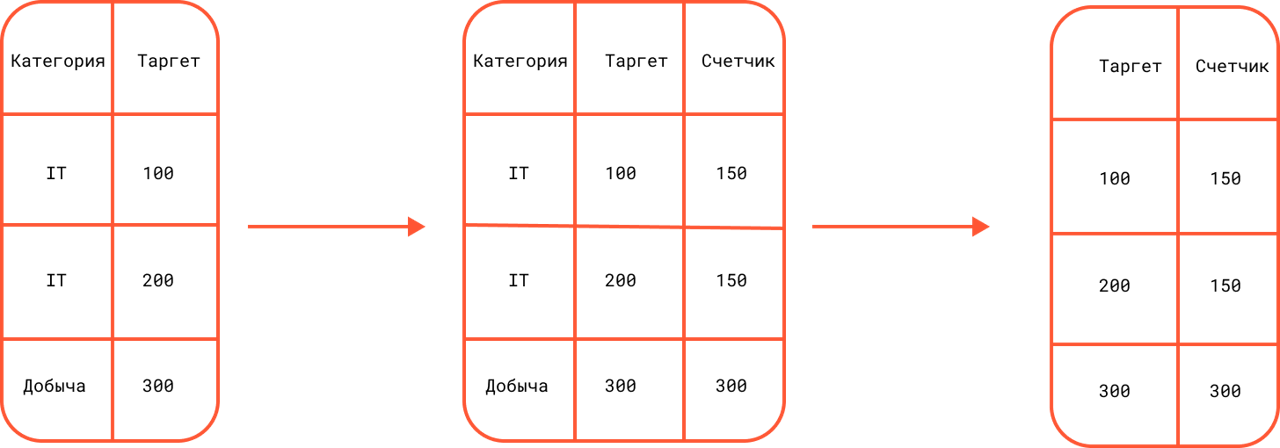

In [111]:
### Apply mean-target encoding to the Category column
data['Category'] = data['Category'].map(data.groupby(['Category'])['Amount raised in dollars'].mean())

In [112]:
data.head()

,Category,Publication date,Investors,Amount raised in dollars,Goal in dollars,target1,Duration,Launch_Year,Close_brent,CAD,...,Design,Fashion,Film & Video,Food,Journalism,Music,Photography,Publishing,Technology,Theater
176128,6035.989239,2009-04-21 21:02:48,30,625.0,1000.0,0.0,39,2009,34.41,False,...,False,True,False,False,False,False,False,False,False,False
241929,3591.033473,2009-04-23 00:07:53,3,22.0,80000.0,0.0,87,2009,34.41,False,...,False,False,True,False,False,False,False,False,False,False
244460,3661.424550,2009-04-24 21:52:03,3,35.0,20.0,1.0,8,2009,34.41,False,...,False,False,False,False,False,False,False,False,False,False
80845,4321.245721,2009-04-25 17:36:21,25,145.0,99.0,1.0,79,2009,34.41,False,...,False,False,False,False,False,False,False,False,True,False
181197,6035.989239,2009-04-27 14:10:39,10,387.0,1900.0,0.0,28,2009,34.41,False,...,False,True,False,False,False,False,False,False,False,False


## Define the Target Variable

In [113]:
data = data.drop('target1', axis=1)

In [114]:
### Split the data into features and target
X = data.drop(['Amount raised in dollars','Publication date'], axis=1)
Y = data['Amount raised in dollars']

In [115]:
X

,Category,Investors,Goal in dollars,Duration,Launch_Year,Close_brent,CAD,CHF,DKK,EUR,...,Design,Fashion,Film & Video,Food,Journalism,Music,Photography,Publishing,Technology,Theater
176128,6035.989239,30,1000.00,39,2009,34.41,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
241929,3591.033473,3,80000.00,87,2009,34.41,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
244460,3661.424550,3,20.00,8,2009,34.41,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
80845,4321.245721,25,99.00,79,2009,34.41,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
181197,6035.989239,10,1900.00,28,2009,34.41,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247730,7635.064778,36,35.98,2,2017,34.41,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
318187,38415.722876,25,271.03,4,2017,66.46,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
264474,6098.303122,6,200.00,3,2017,65.99,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
293634,38415.722876,7,250.00,1,2017,66.16,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [116]:
Y

176128    625.00
241929     22.00
244460     35.00
80845     145.00
181197    387.00
           ...  
247730    269.84
318187    544.77
264474    202.00
293634    265.00
23315     513.60
Name: Amount raised in dollars, Length: 331675, dtype: float64

### sklearn

In [ ]:
### Now the magic happens!
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, Y)
# string to float 

X['Prediction'] = model.predict(X)

X.head()

,Category,Investors,Goal in dollars,Duration,Launch_Year,Close_brent,CAD,CHF,DKK,EUR,...,Fashion,Film & Video,Food,Journalism,Music,Photography,Publishing,Technology,Theater,Prediction
176128,6035.989239,30,1000.0,39,2009,34.41,False,False,False,False,...,True,False,False,False,False,False,False,False,False,1483.174972
241929,3591.033473,3,80000.0,87,2009,34.41,False,False,False,False,...,False,True,False,False,False,False,False,False,False,1794.287639
244460,3661.424550,3,20.0,8,2009,34.41,False,False,False,False,...,False,False,False,False,False,False,False,False,False,-3256.358057
80845,4321.245721,25,99.0,79,2009,34.41,False,False,False,False,...,False,False,False,False,False,False,False,True,False,3757.435128
181197,6035.989239,10,1900.0,28,2009,34.41,False,False,False,False,...,True,False,False,False,False,False,False,False,False,-747.682762


In [118]:
data.head()

,Category,Publication date,Investors,Amount raised in dollars,Goal in dollars,Duration,Launch_Year,Close_brent,CAD,CHF,...,Design,Fashion,Film & Video,Food,Journalism,Music,Photography,Publishing,Technology,Theater
176128,6035.989239,2009-04-21 21:02:48,30,625.0,1000.0,39,2009,34.41,False,False,...,False,True,False,False,False,False,False,False,False,False
241929,3591.033473,2009-04-23 00:07:53,3,22.0,80000.0,87,2009,34.41,False,False,...,False,False,True,False,False,False,False,False,False,False
244460,3661.424550,2009-04-24 21:52:03,3,35.0,20.0,8,2009,34.41,False,False,...,False,False,False,False,False,False,False,False,False,False
80845,4321.245721,2009-04-25 17:36:21,25,145.0,99.0,79,2009,34.41,False,False,...,False,False,False,False,False,False,False,False,True,False
181197,6035.989239,2009-04-27 14:10:39,10,387.0,1900.0,28,2009,34.41,False,False,...,False,True,False,False,False,False,False,False,False,False


In [119]:
# Save the result to data.csv
data.to_csv('data.csv', index=False)